# 08 Verification and Convergence

This notebook checks whether the Monte Carlo model behaves in a way that is consistent with the project proposal. The focus is verification and robustness, rather than validation against measured plant data.

The checks are:

| Proposal requirement | How it is checked in this notebook |
|---|---|
| Conservation of load propagation through the cascade | Recompute HVAC, CW and FW cascade totals from local loads and check that the upstream load is passed downstream once only |
| Enforcement of physical bounds on sampled values | Check that sampled loads remain non-negative and within the lower and upper uncertainty bounds |
| Consistency of overload probabilities with increasing uncertainty | Check that overload probability and P99 load-to-capacity ratio do not reduce as the margin case increases from A to B to C |
| Monte Carlo convergence | Re-run the worst dependent case at increasing sample sizes and monitor the stability of overload probability and P99 load-to-capacity ratio |

I include P99 load-to-capacity ratio alongside overload probability because several independent cases have zero overloads. In those cases, the rule-of-three bound is more informative than a forced probability estimate, and P99 ratio still shows proximity to the capacity limit.

## Imports and paths

In [1]:
from pathlib import Path
import math
import warnings

import numpy as np
import pandas as pd

try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    plotting_available = True
except ModuleNotFoundError:
    plotting_available = False

try:
    from scipy.special import ndtr
    from scipy.stats import truncnorm
    scipy_available = True
except ModuleNotFoundError:
    scipy_available = False

warnings.filterwarnings("ignore", category=FutureWarning)


def find_project_root():
    candidates = [Path.cwd(), *Path.cwd().parents]
    for candidate in candidates:
        if (
            (candidate / "outputs" / "tables" / "deterministic_cascade_loads.csv").exists()
            and (candidate / "outputs" / "tables" / "dependency_results_summary.csv").exists()
        ):
            return candidate
    raise FileNotFoundError("Could not find the project root. Please open VS Code at the repository folder.")


project_root = find_project_root()
tables_output_path = project_root / "outputs" / "tables"
figures_output_path = project_root / "outputs" / "figures"
tables_output_path.mkdir(parents=True, exist_ok=True)
figures_output_path.mkdir(parents=True, exist_ok=True)

print(f"Project root: {project_root}")
print(f"Tables output path: {tables_output_path}")
print(f"Figures output path: {figures_output_path}")

Project root: C:\Users\hburg\Documents\Codex\2026-06-26\github-plugin-github-openai-curated-remote\work\Monte-Carlo-Simulation-of-a-Cascading-Cooling-System
Tables output path: C:\Users\hburg\Documents\Codex\2026-06-26\github-plugin-github-openai-curated-remote\work\Monte-Carlo-Simulation-of-a-Cascading-Cooling-System\outputs\tables
Figures output path: C:\Users\hburg\Documents\Codex\2026-06-26\github-plugin-github-openai-curated-remote\work\Monte-Carlo-Simulation-of-a-Cascading-Cooling-System\outputs\figures


## Load previous-stage outputs

In [2]:
deterministic_local_loads = pd.read_csv(tables_output_path / "deterministic_local_loads.csv")
deterministic_cascade_loads = pd.read_csv(tables_output_path / "deterministic_cascade_loads.csv")
deterministic_no_double_counting_check = pd.read_csv(tables_output_path / "deterministic_no_double_counting_check.csv")
uncertainty_sampling_validation = pd.read_csv(tables_output_path / "uncertainty_sampling_validation.csv")
uncertainty_degenerate_sampling_check = pd.read_csv(tables_output_path / "uncertainty_degenerate_sampling_check.csv")
uncertainty_distribution_parameters = pd.read_csv(tables_output_path / "uncertainty_distribution_parameters.csv")
monte_carlo_results = pd.read_csv(tables_output_path / "monte_carlo_results_summary.csv")
dependency_results = pd.read_csv(tables_output_path / "dependency_results_summary.csv")

print(f"Loaded {len(uncertainty_distribution_parameters):,} uncertainty parameter rows")
print(f"Loaded {len(monte_carlo_results):,} independent Monte Carlo result rows")
print(f"Loaded {len(dependency_results):,} dependency result rows")

Loaded 15,534 uncertainty parameter rows
Loaded 36 independent Monte Carlo result rows
Loaded 216 dependency result rows


## Verification settings

In [3]:
FOCUS_SCENARIO = "Scenario Bravo"
FOCUS_MARGIN_CASE = "Case C - CMM + CUM + DBM + IGM"
FOCUS_DISTRIBUTION = "Truncated normal"
FOCUS_DEPENDENCY_MODEL = "Global Gaussian copula"
FOCUS_RHO = 0.75
FOCUS_SUBSYSTEM = "FW"

CONVERGENCE_SAMPLE_SIZES = sorted(set(
    np.rint(np.geomspace(100, 1_000_000, 70)).astype(int).tolist()
    + [1_000, 5_000, 10_000, 25_000, 50_000, 100_000, 250_000, 500_000, 1_000_000]
))
MAX_CONVERGENCE_SAMPLES = max(CONVERGENCE_SAMPLE_SIZES)
CONVERGENCE_CHUNK_SIZE = 25_000
RANDOM_SEED = 19046600 + 8

P99_RATIO_STABILITY_TOLERANCE = 0.005
OVERLOAD_PROBABILITY_STABILITY_TOLERANCE_PCT = 0.5
CASCADE_TOLERANCE_KW = 1e-6
WORKBOOK_ROUNDING_TOLERANCE_KW = 0.05

verification_settings = pd.DataFrame([
    {"Parameter": "Focused scenario", "Value": FOCUS_SCENARIO},
    {"Parameter": "Focused uncertainty case", "Value": FOCUS_MARGIN_CASE},
    {"Parameter": "Focused distribution", "Value": FOCUS_DISTRIBUTION},
    {"Parameter": "Focused dependency model", "Value": FOCUS_DEPENDENCY_MODEL},
    {"Parameter": "Focused latent correlation", "Value": FOCUS_RHO},
    {"Parameter": "Target subsystem", "Value": FOCUS_SUBSYSTEM},
    {"Parameter": "Maximum convergence sample size", "Value": f"{MAX_CONVERGENCE_SAMPLES:,}"},
    {"Parameter": "Convergence sample sizes", "Value": "70 log-spaced cumulative points from 100 to 1,000,000, including 100k, 250k and 500k"},
    {"Parameter": "Chunk size", "Value": f"{CONVERGENCE_CHUNK_SIZE:,}"},
    {"Parameter": "Random seed", "Value": RANDOM_SEED},
    {"Parameter": "P99 ratio stability tolerance", "Value": P99_RATIO_STABILITY_TOLERANCE},
    {"Parameter": "Overload probability stability tolerance", "Value": f"{OVERLOAD_PROBABILITY_STABILITY_TOLERANCE_PCT} percentage points"},
])

verification_settings.to_csv(tables_output_path / "verification_simulation_settings.csv", index=False)
display(verification_settings)


,Parameter,Value
0,Focused scenario,Scenario Bravo
1,Focused uncertainty case,Case C - CMM + CUM + DBM + IGM
2,Focused distribution,Truncated normal
3,Focused dependency model,Global Gaussian copula
4,Focused latent correlation,0.75
5,Target subsystem,FW
6,Maximum convergence sample size,"1,000,000"
7,Convergence sample sizes,"70 log-spaced cumulative points from 100 to 1,..."
8,Chunk size,"25,000"
9,Random seed,19046608


## Check 1: conservation of load propagation

The cascade should conserve load as it moves downstream. In this project that means:

* HVAC total is the local HVAC load.
* CW total is local CW load plus the HVAC total.
* FW total is local FW load plus the CW total.

The embedded workbook propagation rows are not summed as local loads because that would count the cascade twice. They are retained only as a rounding check against the recomputed propagation values.

In [4]:
local = deterministic_local_loads.set_index("subsystem")
cascade = deterministic_cascade_loads.set_index("subsystem")

scenario_columns = {
    "Scenario Alpha": {
        "local": "scenario_alpha_local_load_kw",
        "cascade": "scenario_alpha_load_kw",
    },
    "Scenario Bravo": {
        "local": "scenario_bravo_local_load_kw",
        "cascade": "scenario_bravo_load_kw",
    },
}

conservation_rows = []
for scenario, columns in scenario_columns.items():
    hvac_expected = local.loc["HVAC", columns["local"]]
    cw_expected = local.loc["CW", columns["local"]] + hvac_expected
    fw_expected = local.loc["FW", columns["local"]] + cw_expected

    expected_by_system = {
        "HVAC": hvac_expected,
        "CW": cw_expected,
        "FW": fw_expected,
    }

    for subsystem, expected_load in expected_by_system.items():
        observed_load = cascade.loc[subsystem, columns["cascade"]]
        conservation_rows.append({
            "scenario": scenario,
            "subsystem": subsystem,
            "expected_cascade_load_kw": expected_load,
            "observed_cascade_load_kw": observed_load,
            "difference_kw": observed_load - expected_load,
            "passes_conservation_check": abs(observed_load - expected_load) <= CASCADE_TOLERANCE_KW,
        })

cascade_conservation_check = pd.DataFrame(conservation_rows)
cascade_conservation_check.to_csv(tables_output_path / "verification_cascade_conservation_check.csv", index=False)

rounding_check = deterministic_no_double_counting_check.copy()
rounding_check["passes_workbook_rounding_check"] = (
    rounding_check["alpha_difference_kw"].abs().le(WORKBOOK_ROUNDING_TOLERANCE_KW)
    & rounding_check["bravo_difference_kw"].abs().le(WORKBOOK_ROUNDING_TOLERANCE_KW)
    & rounding_check["excluded_from_local_sum"].astype(bool)
)
rounding_check.to_csv(tables_output_path / "verification_embedded_workbook_rounding_check.csv", index=False)

display(cascade_conservation_check)
display(rounding_check)

,scenario,subsystem,expected_cascade_load_kw,observed_cascade_load_kw,difference_kw,passes_conservation_check
0,Scenario Alpha,HVAC,1026.733447,1026.733447,0.000000e+00,True
1,Scenario Alpha,CW,3814.611478,3814.611478,0.000000e+00,True
2,Scenario Alpha,FW,11172.365578,11172.365578,0.000000e+00,True
3,Scenario Bravo,HVAC,307.292472,307.292472,0.000000e+00,True
4,Scenario Bravo,CW,1256.638670,1256.638670,2.273737e-13,True
5,Scenario Bravo,FW,4636.317393,4636.317393,0.000000e+00,True


,propagation_type,embedded_row,downstream_system,excluded_from_local_sum,recomputed_upstream_alpha_kw,embedded_alpha_kw,recomputed_upstream_bravo_kw,embedded_bravo_kw,alpha_difference_kw,bravo_difference_kw,passes_workbook_rounding_check
0,hvac_to_cw,ITEM_000955,CW,True,1026.733447,1026.76,307.292472,307.29,-0.026553,0.002472,True
1,cw_to_fw,ITEM_001103,FW,True,3814.611478,3814.64,1256.638670,1256.64,-0.028522,-0.001330,True


## Check 2: physical bounds on sampled values

The uncertainty model should not create physically impossible loads. This check uses the sampling validation from Notebook 04 and then repeats the same idea on the focused convergence sample created later in this notebook.

The required behaviour is that sampled loads remain non-negative, and that non-degenerate rows stay within the lower and upper uncertainty bounds.

In [5]:
bounds_check = pd.DataFrame([
    {
        "check": "Notebook 04 validation samples are non-negative",
        "passed": uncertainty_sampling_validation["non_negative_check"].astype(bool).all(),
        "failing_rows": int((~uncertainty_sampling_validation["non_negative_check"].astype(bool)).sum()),
    },
    {
        "check": "Notebook 04 validation samples are within bounds",
        "passed": uncertainty_sampling_validation["within_bounds_check"].astype(bool).all(),
        "failing_rows": int((~uncertainty_sampling_validation["within_bounds_check"].astype(bool)).sum()),
    },
    {
        "check": "Degenerate zero-load rows remain equal to nominal",
        "passed": uncertainty_degenerate_sampling_check["all_samples_equal_nominal"].astype(bool).all(),
        "failing_rows": int((~uncertainty_degenerate_sampling_check["all_samples_equal_nominal"].astype(bool)).sum()),
    },
])

bounds_check.to_csv(tables_output_path / "verification_sampling_bounds_check.csv", index=False)
display(bounds_check)

,check,passed,failing_rows
0,Notebook 04 validation samples are non-negative,True,0
1,Notebook 04 validation samples are within bounds,True,0
2,Degenerate zero-load rows remain equal to nominal,True,0


## Check 3: consistency with increasing uncertainty

The uncertainty margin cases are ordered from lower uncertainty to higher uncertainty:

* Case A - CUM
* Case B - CMM + CUM
* Case C - CMM + CUM + DBM + IGM

The estimated overload probability should not reduce as the uncertainty case increases. I also check P99 load-to-capacity ratio because this remains informative when all overload probabilities are zero.

In [6]:
margin_case_order = {
    "Case A - CUM": 1,
    "Case B - CMM + CUM": 2,
    "Case C - CMM + CUM + DBM + IGM": 3,
}


def monotonic_check(data, group_columns, source_label):
    rows = []
    working = data.copy()
    working["margin_case_order"] = working["margin_case"].map(margin_case_order)

    for keys, group in working.sort_values("margin_case_order").groupby(group_columns):
        if not isinstance(keys, tuple):
            keys = (keys,)

        ordered = group.sort_values("margin_case_order")
        overload_values = ordered["overload_probability_pct"].astype(float).to_numpy()
        p99_ratio_values = ordered["p99_load_to_capacity_ratio"].astype(float).to_numpy()

        row = {"source": source_label}
        row.update(dict(zip(group_columns, keys)))
        row.update({
            "overload_case_a_pct": overload_values[0],
            "overload_case_b_pct": overload_values[1],
            "overload_case_c_pct": overload_values[2],
            "p99_ratio_case_a": p99_ratio_values[0],
            "p99_ratio_case_b": p99_ratio_values[1],
            "p99_ratio_case_c": p99_ratio_values[2],
            "overload_probability_monotonic": bool(np.all(np.diff(overload_values) >= -1e-12)),
            "p99_ratio_monotonic": bool(np.all(np.diff(p99_ratio_values) >= -1e-12)),
        })
        rows.append(row)

    return pd.DataFrame(rows)


independent_monotonicity = monotonic_check(
    monte_carlo_results,
    ["scenario", "distribution_model", "subsystem"],
    "Independent Monte Carlo",
)

dependency_monotonicity = monotonic_check(
    dependency_results,
    ["scenario", "distribution_model", "dependency_model", "rho", "subsystem"],
    "Dependency Monte Carlo",
)

uncertainty_monotonicity_check = pd.concat(
    [independent_monotonicity, dependency_monotonicity],
    ignore_index=True,
    sort=False,
)

uncertainty_monotonicity_check["passed"] = (
    uncertainty_monotonicity_check["overload_probability_monotonic"]
    & uncertainty_monotonicity_check["p99_ratio_monotonic"]
)

uncertainty_monotonicity_check.to_csv(tables_output_path / "verification_uncertainty_monotonicity_check.csv", index=False)

monotonicity_summary = uncertainty_monotonicity_check.groupby("source").agg(
    checks=("passed", "size"),
    passed_checks=("passed", "sum"),
    failed_checks=("passed", lambda values: int((~values).sum())),
).reset_index()

monotonicity_summary.to_csv(tables_output_path / "verification_uncertainty_monotonicity_summary.csv", index=False)

display(monotonicity_summary)
display(uncertainty_monotonicity_check.loc[~uncertainty_monotonicity_check["passed"]].head())

,source,checks,passed_checks,failed_checks
0,Dependency Monte Carlo,72,72,0
1,Independent Monte Carlo,12,12,0


,source,scenario,distribution_model,subsystem,overload_case_a_pct,overload_case_b_pct,overload_case_c_pct,p99_ratio_case_a,p99_ratio_case_b,p99_ratio_case_c,overload_probability_monotonic,p99_ratio_monotonic,dependency_model,rho,passed


## Check 4: convergence of the worst dependent case

For convergence I focus on the worst dependent case identified in Notebook 06. This is the most useful convergence target because it has a non-zero overload probability. In no-overload cases, convergence of an estimated probability is less informative because the estimate remains zero and the rule-of-three upper bound is the more honest interpretation.

I generate one extended 1,000,000-sample run and then evaluate many increasing cumulative prefixes of that run. This produces a smoother convergence trace: the early points show sampling noise, while the later points show whether the estimate settles down.

The final 1,000,000-sample value is used as a practical long-run reference line. It is not treated as a true analytical value, because no measured or closed-form benchmark exists for this cascade model. The important comparison is whether the 100,000-sample result used in the earlier notebooks is already close to this longer-run reference.


In [7]:
if not scipy_available:
    raise ModuleNotFoundError("scipy is required for the convergence simulation.")


def make_bool(series):
    return series.astype(str).str.lower().eq("true")


def simulate_focused_global_copula(parameters, n_samples, rho, random_seed, chunk_size):
    rng = np.random.default_rng(random_seed)

    working = parameters.copy()
    working["is_degenerate_bool"] = make_bool(working["is_degenerate"])

    variable_parameters = working.loc[~working["is_degenerate_bool"]].reset_index(drop=True)
    degenerate_parameters = working.loc[working["is_degenerate_bool"]].reset_index(drop=True)

    system_order = ["HVAC", "CW", "FW"]
    base_local_loads = {
        system: float(degenerate_parameters.loc[
            degenerate_parameters["system"] == system,
            "nominal_load_kw",
        ].sum())
        for system in system_order
    }

    systems = variable_parameters["system"].to_numpy()
    lower = variable_parameters["truncnorm_lower_kw"].to_numpy(dtype=float)
    mean = variable_parameters["truncnorm_mean_kw"].to_numpy(dtype=float)
    upper = variable_parameters["truncnorm_upper_kw"].to_numpy(dtype=float)
    sigma = variable_parameters["truncnorm_sigma_kw"].to_numpy(dtype=float)
    a_values = (lower - mean) / sigma
    b_values = (upper - mean) / sigma

    sqrt_rho = math.sqrt(rho)
    sqrt_one_minus_rho = math.sqrt(1 - rho)

    target_load = np.empty(n_samples, dtype=np.float32)
    bounds_tracker = {
        system: {
            "sample_min_kw": np.inf,
            "sample_max_kw": -np.inf,
            "non_negative_check": True,
            "within_row_bounds_check": True,
        }
        for system in system_order
    }

    for start in range(0, n_samples, chunk_size):
        end = min(start + chunk_size, n_samples)
        current_size = end - start
        common_factor = rng.normal(size=current_size)

        local_loads = {
            system: np.full(current_size, base_local_loads[system], dtype=np.float64)
            for system in system_order
        }

        for row_index in range(len(variable_parameters)):
            independent_factor = rng.normal(size=current_size)
            normal_scores = sqrt_rho * common_factor + sqrt_one_minus_rho * independent_factor
            uniform_scores = np.clip(ndtr(normal_scores), 1e-12, 1 - 1e-12)

            sampled_load = truncnorm.ppf(
                uniform_scores,
                a_values[row_index],
                b_values[row_index],
                loc=mean[row_index],
                scale=sigma[row_index],
            )

            system = systems[row_index]
            local_loads[system] += sampled_load

            bounds_tracker[system]["sample_min_kw"] = min(
                bounds_tracker[system]["sample_min_kw"],
                float(sampled_load.min()),
            )
            bounds_tracker[system]["sample_max_kw"] = max(
                bounds_tracker[system]["sample_max_kw"],
                float(sampled_load.max()),
            )
            bounds_tracker[system]["non_negative_check"] = (
                bounds_tracker[system]["non_negative_check"]
                and bool(sampled_load.min() >= -1e-9)
            )
            bounds_tracker[system]["within_row_bounds_check"] = (
                bounds_tracker[system]["within_row_bounds_check"]
                and bool(np.all(sampled_load >= lower[row_index] - 1e-6))
                and bool(np.all(sampled_load <= upper[row_index] + 1e-6))
            )

        cascade_load = local_loads["HVAC"] + local_loads["CW"] + local_loads["FW"]
        target_load[start:end] = cascade_load.astype(np.float32)

    bounds_rows = []
    for system in system_order:
        system_parameters = variable_parameters.loc[variable_parameters["system"] == system]
        bounds_rows.append({
            "system": system,
            "sample_min_kw": bounds_tracker[system]["sample_min_kw"],
            "sample_max_kw": bounds_tracker[system]["sample_max_kw"],
            "lower_bound_min_kw": float(system_parameters["truncnorm_lower_kw"].min()),
            "upper_bound_max_kw": float(system_parameters["truncnorm_upper_kw"].max()),
            "non_negative_check": bounds_tracker[system]["non_negative_check"],
            "within_row_bounds_check": bounds_tracker[system]["within_row_bounds_check"],
        })

    focused_bounds_check = pd.DataFrame(bounds_rows)
    return target_load, focused_bounds_check, variable_parameters


focused_parameters = uncertainty_distribution_parameters[
    (uncertainty_distribution_parameters["scenario"] == FOCUS_SCENARIO)
    & (uncertainty_distribution_parameters["margin_case"] == FOCUS_MARGIN_CASE)
].copy()

focused_target_load, focused_bounds_check, focused_variable_parameters = simulate_focused_global_copula(
    focused_parameters,
    MAX_CONVERGENCE_SAMPLES,
    FOCUS_RHO,
    RANDOM_SEED,
    CONVERGENCE_CHUNK_SIZE,
)

focused_bounds_check.to_csv(tables_output_path / "verification_focused_sampling_bounds_check.csv", index=False)

display(focused_bounds_check)
print(f"Focused variable rows: {len(focused_variable_parameters):,}")
print(f"Convergence samples generated: {len(focused_target_load):,}")


,system,sample_min_kw,sample_max_kw,lower_bound_min_kw,upper_bound_max_kw,non_negative_check,within_row_bounds_check
0,HVAC,0.000971,55.384587,0.000971,55.38462,True,True
1,CW,0.000004,94.774834,0.000004,94.77504,True,True
2,FW,0.050192,1001.695747,0.050191,1001.69867,True,True


Focused variable rows: 447
Convergence samples generated: 1,000,000


In [8]:
capacity_row = dependency_results[
    (dependency_results["scenario"] == FOCUS_SCENARIO)
    & (dependency_results["margin_case"] == FOCUS_MARGIN_CASE)
    & (dependency_results["distribution_model"] == FOCUS_DISTRIBUTION)
    & (dependency_results["dependency_model"] == FOCUS_DEPENDENCY_MODEL)
    & (dependency_results["rho"] == FOCUS_RHO)
    & (dependency_results["subsystem"] == FOCUS_SUBSYSTEM)
].iloc[0]

focused_capacity_kw = float(capacity_row["capacity_kw"])

convergence_rows = []
for sample_size in CONVERGENCE_SAMPLE_SIZES:
    sample = focused_target_load[:sample_size]
    overload = sample > focused_capacity_kw
    overload_probability = overload.mean()
    standard_error = math.sqrt(overload_probability * (1 - overload_probability) / sample_size)

    convergence_rows.append({
        "sample_size": sample_size,
        "subsystem": FOCUS_SUBSYSTEM,
        "capacity_kw": focused_capacity_kw,
        "mean_load_kw": sample.mean(),
        "p95_load_kw": np.percentile(sample, 95),
        "p99_load_kw": np.percentile(sample, 99),
        "p99_load_to_capacity_ratio": np.percentile(sample, 99) / focused_capacity_kw,
        "overload_count": int(overload.sum()),
        "overload_probability": overload_probability,
        "overload_probability_pct": overload_probability * 100,
        "overload_probability_ci95_lower_pct": max(0, overload_probability - 1.96 * standard_error) * 100,
        "overload_probability_ci95_upper_pct": min(1, overload_probability + 1.96 * standard_error) * 100,
        "rule_of_three_upper_if_zero": (3 / sample_size) if overload.sum() == 0 else np.nan,
    })

convergence_results = pd.DataFrame(convergence_rows)
convergence_results["previous_overload_probability_pct"] = convergence_results["overload_probability_pct"].shift(1)
convergence_results["previous_p99_load_to_capacity_ratio"] = convergence_results["p99_load_to_capacity_ratio"].shift(1)
convergence_results["change_from_previous_probability_pct_points"] = (
    convergence_results["overload_probability_pct"]
    - convergence_results["previous_overload_probability_pct"]
)
convergence_results["change_from_previous_p99_ratio"] = (
    convergence_results["p99_load_to_capacity_ratio"]
    - convergence_results["previous_p99_load_to_capacity_ratio"]
)

convergence_results.to_csv(tables_output_path / "verification_convergence_results.csv", index=False)


def convergence_comparison(reference_size, final_size=1_000_000):
    reference_row = convergence_results.loc[
        convergence_results["sample_size"] == reference_size
    ].iloc[0]
    final_row = convergence_results.loc[
        convergence_results["sample_size"] == final_size
    ].iloc[0]

    return [
        {
            "comparison": f"{reference_size:,} vs {final_size:,}",
            "metric": "P99 load-to-capacity ratio",
            "reference_sample_size": reference_size,
            "final_sample_size": final_size,
            "reference_value": reference_row["p99_load_to_capacity_ratio"],
            "final_value": final_row["p99_load_to_capacity_ratio"],
            "absolute_change": abs(final_row["p99_load_to_capacity_ratio"] - reference_row["p99_load_to_capacity_ratio"]),
            "relative_change": abs(final_row["p99_load_to_capacity_ratio"] - reference_row["p99_load_to_capacity_ratio"]) / reference_row["p99_load_to_capacity_ratio"],
            "tolerance": P99_RATIO_STABILITY_TOLERANCE,
            "passed": abs(final_row["p99_load_to_capacity_ratio"] - reference_row["p99_load_to_capacity_ratio"]) / reference_row["p99_load_to_capacity_ratio"] <= P99_RATIO_STABILITY_TOLERANCE,
        },
        {
            "comparison": f"{reference_size:,} vs {final_size:,}",
            "metric": "Overload probability",
            "reference_sample_size": reference_size,
            "final_sample_size": final_size,
            "reference_value": reference_row["overload_probability_pct"],
            "final_value": final_row["overload_probability_pct"],
            "absolute_change": abs(final_row["overload_probability_pct"] - reference_row["overload_probability_pct"]),
            "relative_change": np.nan,
            "tolerance": OVERLOAD_PROBABILITY_STABILITY_TOLERANCE_PCT,
            "passed": abs(final_row["overload_probability_pct"] - reference_row["overload_probability_pct"]) <= OVERLOAD_PROBABILITY_STABILITY_TOLERANCE_PCT,
        },
    ]


stability_rows = []
for reference_size in [50_000, 100_000, 250_000, 500_000]:
    stability_rows.extend(convergence_comparison(reference_size))

convergence_stability = pd.DataFrame(stability_rows)
convergence_stability.to_csv(tables_output_path / "verification_convergence_stability.csv", index=False)

notebook06_comparison = pd.DataFrame([{
    "comparison": "Notebook 08 extended convergence run vs Notebook 06 stored 100k result",
    "notebook06_overload_probability_pct": float(capacity_row["overload_probability_pct"]),
    "notebook08_100k_overload_probability_pct": convergence_results.loc[convergence_results["sample_size"] == 100_000, "overload_probability_pct"].iloc[0],
    "notebook08_1m_overload_probability_pct": convergence_results.loc[convergence_results["sample_size"] == 1_000_000, "overload_probability_pct"].iloc[0],
    "notebook06_p99_load_to_capacity_ratio": float(capacity_row["p99_load_to_capacity_ratio"]),
    "notebook08_100k_p99_load_to_capacity_ratio": convergence_results.loc[convergence_results["sample_size"] == 100_000, "p99_load_to_capacity_ratio"].iloc[0],
    "notebook08_1m_p99_load_to_capacity_ratio": convergence_results.loc[convergence_results["sample_size"] == 1_000_000, "p99_load_to_capacity_ratio"].iloc[0],
}])
notebook06_comparison.to_csv(tables_output_path / "verification_convergence_against_notebook06.csv", index=False)

display(convergence_results.tail(12))
display(convergence_stability)
display(notebook06_comparison)


,sample_size,subsystem,capacity_kw,mean_load_kw,p95_load_kw,p99_load_kw,p99_load_to_capacity_ratio,overload_count,overload_probability,overload_probability_pct,overload_probability_ci95_lower_pct,overload_probability_ci95_upper_pct,rule_of_three_upper_if_zero,previous_overload_probability_pct,previous_p99_load_to_capacity_ratio,change_from_previous_probability_pct_points,change_from_previous_p99_ratio
66,263202,FW,4871.78,4635.901367,4919.326587,5002.276851,1.026786,23956,0.091018,9.101755,8.991866,9.211643,NaN,9.111600,1.026787,-0.009845,-6.083746e-07
67,300788,FW,4871.78,4635.865723,4919.438257,5002.280166,1.026787,27419,0.091157,9.115723,9.012858,9.218587,NaN,9.101755,1.026786,0.013968,6.805376e-07
68,343741,FW,4871.78,4636.059082,4919.465820,5002.533594,1.026839,31330,0.091144,9.114420,9.018203,9.210638,NaN,9.115723,1.026787,-0.001302,5.201954e-05
69,392828,FW,4871.78,4635.972168,4919.326147,5002.386885,1.026809,35787,0.091101,9.110094,9.020108,9.200080,NaN,9.114420,1.026839,-0.004326,-3.011404e-05
70,448925,FW,4871.78,4635.790527,4919.172461,5002.572285,1.026847,40851,0.090997,9.099738,9.015605,9.183871,NaN,9.110094,1.026809,-0.010356,3.805599e-05
71,500000,FW,4871.78,4635.854980,4919.057690,5002.352617,1.026802,45492,0.090984,9.098400,9.018685,9.178115,NaN,9.099738,1.026847,-0.001338,-4.508988e-05
72,513033,FW,4871.78,4635.858398,4918.969043,5002.341270,1.026800,46631,0.090893,9.089279,9.010619,9.167939,NaN,9.098400,1.026802,-0.009121,-2.329263e-06
73,586295,FW,4871.78,4635.817383,4918.896143,5002.363369,1.026804,53146,0.090647,9.064720,8.991228,9.138212,NaN,9.089279,1.026800,-0.024559,4.536249e-06
74,670019,FW,4871.78,4635.885742,4918.869629,5002.364482,1.026804,60745,0.090662,9.066161,8.997409,9.134913,NaN,9.064720,1.026804,0.001441,2.285163e-07
75,765699,FW,4871.78,4636.038086,4918.900000,5002.100635,1.026750,69487,0.090750,9.074976,9.010634,9.139317,NaN,9.066161,1.026804,0.008815,-5.415837e-05


,comparison,metric,reference_sample_size,final_sample_size,reference_value,final_value,absolute_change,relative_change,tolerance,passed
0,"50,000 vs 1,000,000",P99 load-to-capacity ratio,50000,1000000,1.026632,1.026731,0.000098,0.000096,0.005,True
1,"50,000 vs 1,000,000",Overload probability,50000,1000000,9.162000,9.067400,0.094600,NaN,0.500,True
2,"100,000 vs 1,000,000",P99 load-to-capacity ratio,100000,1000000,1.026847,1.026731,0.000116,0.000113,0.005,True
3,"100,000 vs 1,000,000",Overload probability,100000,1000000,9.178000,9.067400,0.110600,NaN,0.500,True
4,"250,000 vs 1,000,000",P99 load-to-capacity ratio,250000,1000000,1.026787,1.026731,0.000056,0.000055,0.005,True
5,"250,000 vs 1,000,000",Overload probability,250000,1000000,9.111600,9.067400,0.044200,NaN,0.500,True
6,"500,000 vs 1,000,000",P99 load-to-capacity ratio,500000,1000000,1.026802,1.026731,0.000071,0.000069,0.005,True
7,"500,000 vs 1,000,000",Overload probability,500000,1000000,9.098400,9.067400,0.031000,NaN,0.500,True


,comparison,notebook06_overload_probability_pct,notebook08_100k_overload_probability_pct,notebook08_1m_overload_probability_pct,notebook06_p99_load_to_capacity_ratio,notebook08_100k_p99_load_to_capacity_ratio,notebook08_1m_p99_load_to_capacity_ratio
0,Notebook 08 extended convergence run vs Notebo...,9.225,9.178,9.0674,1.026979,1.026847,1.026731


## Verification figures

<Figure size 900x500 with 0 Axes>

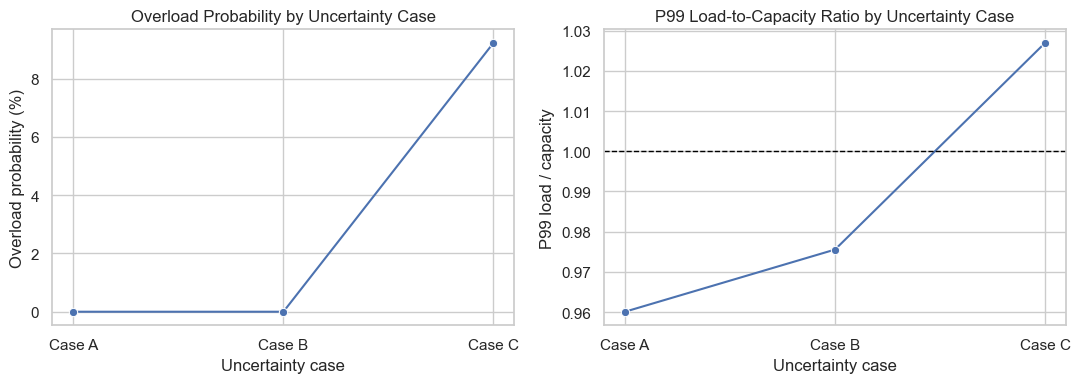

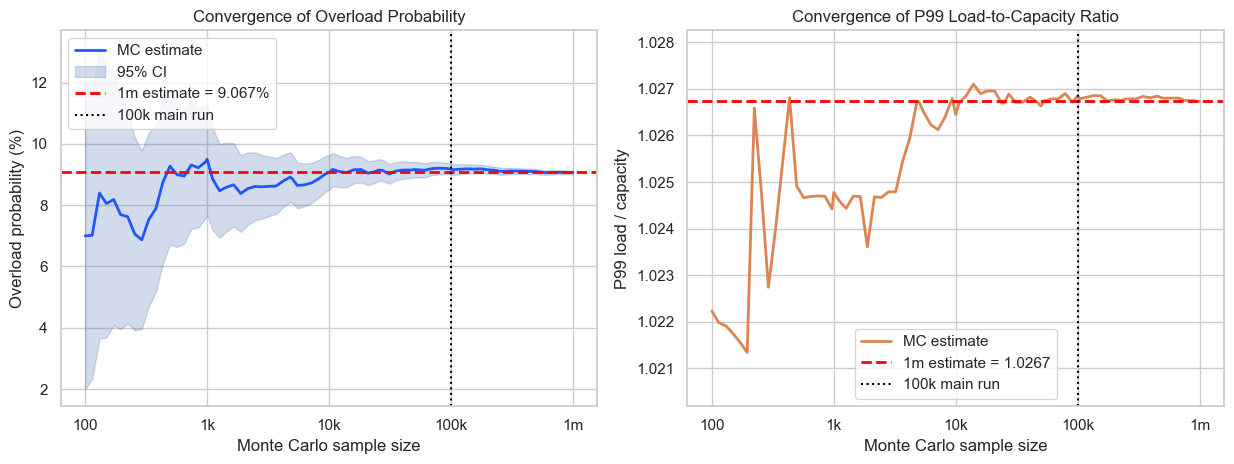

In [9]:
if plotting_available:
    sns.set_theme(style="whitegrid")

    plt.figure(figsize=(9, 5))
    focused_uncertainty = uncertainty_monotonicity_check[
        (uncertainty_monotonicity_check["source"] == "Dependency Monte Carlo")
        & (uncertainty_monotonicity_check["scenario"] == FOCUS_SCENARIO)
        & (uncertainty_monotonicity_check["distribution_model"] == FOCUS_DISTRIBUTION)
        & (uncertainty_monotonicity_check["dependency_model"] == FOCUS_DEPENDENCY_MODEL)
        & (uncertainty_monotonicity_check["rho"] == FOCUS_RHO)
        & (uncertainty_monotonicity_check["subsystem"] == FOCUS_SUBSYSTEM)
    ].iloc[0]

    uncertainty_plot_data = pd.DataFrame({
        "margin_case": ["Case A", "Case B", "Case C"],
        "overload_probability_pct": [
            focused_uncertainty["overload_case_a_pct"],
            focused_uncertainty["overload_case_b_pct"],
            focused_uncertainty["overload_case_c_pct"],
        ],
        "p99_load_to_capacity_ratio": [
            focused_uncertainty["p99_ratio_case_a"],
            focused_uncertainty["p99_ratio_case_b"],
            focused_uncertainty["p99_ratio_case_c"],
        ],
    })

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    sns.lineplot(data=uncertainty_plot_data, x="margin_case", y="overload_probability_pct", marker="o", ax=axes[0])
    axes[0].set_title("Overload Probability by Uncertainty Case")
    axes[0].set_xlabel("Uncertainty case")
    axes[0].set_ylabel("Overload probability (%)")

    sns.lineplot(data=uncertainty_plot_data, x="margin_case", y="p99_load_to_capacity_ratio", marker="o", ax=axes[1])
    axes[1].axhline(1.0, color="black", linewidth=1, linestyle="--")
    axes[1].set_title("P99 Load-to-Capacity Ratio by Uncertainty Case")
    axes[1].set_xlabel("Uncertainty case")
    axes[1].set_ylabel("P99 load / capacity")
    plt.tight_layout()
    plt.savefig(figures_output_path / "verification_uncertainty_monotonicity.png", dpi=150, bbox_inches="tight")
    plt.show()

    convergence_plot_data = convergence_results.copy()
    final_probability = convergence_plot_data.loc[
        convergence_plot_data["sample_size"] == 1_000_000,
        "overload_probability_pct",
    ].iloc[0]
    final_p99_ratio = convergence_plot_data.loc[
        convergence_plot_data["sample_size"] == 1_000_000,
        "p99_load_to_capacity_ratio",
    ].iloc[0]

    fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))
    axes[0].plot(
        convergence_plot_data["sample_size"],
        convergence_plot_data["overload_probability_pct"],
        color="#1f57ff",
        linewidth=2,
        label="MC estimate",
    )
    axes[0].fill_between(
        convergence_plot_data["sample_size"],
        convergence_plot_data["overload_probability_ci95_lower_pct"],
        convergence_plot_data["overload_probability_ci95_upper_pct"],
        color="#4c72b0",
        alpha=0.25,
        label="95% CI",
    )
    axes[0].axhline(final_probability, color="red", linestyle="--", linewidth=2, label=f"1m estimate = {final_probability:.3f}%")
    axes[0].axvline(100_000, color="black", linestyle=":", linewidth=1.5, label="100k main run")
    axes[0].set_xscale("log")
    axes[0].set_title("Convergence of Overload Probability")
    axes[0].set_xlabel("Monte Carlo sample size")
    axes[0].set_ylabel("Overload probability (%)")
    axes[0].legend(loc="best")

    axes[1].plot(
        convergence_plot_data["sample_size"],
        convergence_plot_data["p99_load_to_capacity_ratio"],
        color="#dd8452",
        linewidth=2,
        label="MC estimate",
    )
    axes[1].axhline(final_p99_ratio, color="red", linestyle="--", linewidth=2, label=f"1m estimate = {final_p99_ratio:.4f}")
    axes[1].axvline(100_000, color="black", linestyle=":", linewidth=1.5, label="100k main run")
    axes[1].set_xscale("log")
    p99_min = convergence_plot_data["p99_load_to_capacity_ratio"].min()
    p99_max = convergence_plot_data["p99_load_to_capacity_ratio"].max()
    p99_padding = max((p99_max - p99_min) * 0.20, 0.0002)
    axes[1].set_ylim(p99_min - p99_padding, p99_max + p99_padding)
    axes[1].set_title("Convergence of P99 Load-to-Capacity Ratio")
    axes[1].set_xlabel("Monte Carlo sample size")
    axes[1].set_ylabel("P99 load / capacity")
    axes[1].legend(loc="best")

    for axis in axes:
        axis.set_xticks([100, 1_000, 10_000, 100_000, 1_000_000])
        axis.set_xticklabels(["100", "1k", "10k", "100k", "1m"])

    plt.tight_layout()
    plt.savefig(figures_output_path / "verification_convergence_worst_case.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Skipping plots because matplotlib and seaborn are not installed.")


## Overall verification summary

In [10]:
verification_summary = pd.DataFrame([
    {
        "proposal_requirement": "Conservation of load propagation through the cascade",
        "evidence": "Recomputed deterministic cascade totals match stored cascade totals, and embedded propagation rows are excluded from local sums.",
        "passed": bool(cascade_conservation_check["passes_conservation_check"].all() and rounding_check["passes_workbook_rounding_check"].all()),
    },
    {
        "proposal_requirement": "Enforcement of physical bounds on sampled values",
        "evidence": "Notebook 04 validation samples and the focused convergence sample remain non-negative and within uncertainty bounds.",
        "passed": bool(bounds_check["passed"].all() and focused_bounds_check["non_negative_check"].all() and focused_bounds_check["within_row_bounds_check"].all()),
    },
    {
        "proposal_requirement": "Consistency of overload probabilities with increasing uncertainty",
        "evidence": "Overload probability and P99 load-to-capacity ratio are monotonic from Case A to Case C across independent and dependency result sets.",
        "passed": bool(uncertainty_monotonicity_check["passed"].all()),
    },
    {
        "proposal_requirement": "Monte Carlo convergence",
        "evidence": "The worst dependent case is re-evaluated from 100 to 1,000,000 cumulative samples. The 100,000-sample result is compared against the 1,000,000-sample long-run reference.",
        "passed": bool(convergence_stability["passed"].all()),
    },
])

verification_summary.to_csv(tables_output_path / "verification_key_findings.csv", index=False)
display(verification_summary)


,proposal_requirement,evidence,passed
0,Conservation of load propagation through the c...,Recomputed deterministic cascade totals match ...,True
1,Enforcement of physical bounds on sampled values,Notebook 04 validation samples and the focused...,True
2,Consistency of overload probabilities with inc...,Overload probability and P99 load-to-capacity ...,True
3,Monte Carlo convergence,The worst dependent case is re-evaluated from ...,True


## Notebook 08 conclusion

The verification checks support the internal consistency of the model. The cascade calculation conserves the propagated load, sampled values remain within the physical uncertainty bounds, and the risk metrics increase as the uncertainty case becomes more conservative.

The extended convergence assessment shows that the estimate is noisy at low sample sizes and then settles as the sample size increases. The final 1,000,000-sample result is used as a practical long-run reference, not as a true analytical value. The 100,000-sample result used in the main notebooks is then compared against this reference to judge whether the original simulation size was sufficient.

Notebook 09 can now use these verification results when discussing the final results and limitations.
